## Business Problem

In logistics operations, on-time delivery is one of the most important indicators of service quality and operational efficiency.

Late deliveries can reduce customer satisfaction, increase operational costs, and weaken supply chain performance.

This project investigates shipping delays using the DataCo supply chain dataset in order to identify which shipping modes, regions, and product categories are most associated with late deliveries, and to suggest practical areas for improvement.

## Data Overview

In this section, we explore the structure of the dataset including number of rows, columns, and data types.

In [14]:
import pandas as pd

df = pd.read_csv('/Users/trantien/project/data.csv', encoding='latin1')

df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [15]:
df.shape

(180519, 53)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname                 180519 non

In [17]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

## Missing Values

We check for missing values in each column.

In [18]:
df.isnull().sum().sort_values(ascending=False)

Product Description              180519
Order Zipcode                    155679
Customer Lname                        8
Customer Zipcode                      3
Type                                  0
Order Profit Per Order                0
Order Item Cardprod Id                0
Order Item Discount                   0
Order Item Discount Rate              0
Order Item Id                         0
Order Item Product Price              0
Order Item Profit Ratio               0
Order Item Quantity                   0
Sales                                 0
Order Item Total                      0
Order Region                          0
order date (DateOrders)               0
Order State                           0
Order Status                          0
Product Card Id                       0
Product Category Id                   0
Product Image                         0
Product Name                          0
Product Price                         0
Product Status                        0


## Data Cleaning

In this section, we clean the dataset to make it suitable for analysis.  
The cleaning process includes:

- checking missing values
- removing unnecessary columns
- removing duplicate records
- reviewing data types
- checking inconsistencies in key categorical variables
- checking outliers in important numerical variables

These steps help improve data quality and make the analysis more reliable.

### Handling Missing Values

We first check missing values in each column to identify data quality issues.

From the initial inspection:
- `Product Description` has all values missing, so it does not provide useful information for analysis.
- `Order Zipcode` has many missing values.
- `Customer Lname` and `Customer Zipcode` have only a few missing values.

Since this project focuses on shipping delay analysis, columns that are not important for answering the project questions can be removed.

In [33]:
df.isnull().sum().sort_values(ascending=False)

Order Zipcode                    155679
Customer Lname                        8
Customer Zipcode                      3
Type                                  0
Order Item Cardprod Id                0
Order Item Discount                   0
Order Item Discount Rate              0
Order Item Id                         0
Order Item Product Price              0
Order Item Profit Ratio               0
Order Item Quantity                   0
Sales                                 0
Order Item Total                      0
Order Profit Per Order                0
Order Region                          0
order date (DateOrders)               0
Order State                           0
Order Status                          0
Product Card Id                       0
Product Category Id                   0
Product Name                          0
Product Price                         0
Product Status                        0
shipping date (DateOrders)            0
Shipping Mode                         0


### Removing Irrelevant or Low-Quality Columns

Some columns are removed because they are either:
- completely missing,
- mostly missing,
- or not relevant to shipping delay analysis.

Removed columns:
- `Product Description`: all values are missing
- `Product Image`: not needed for logistics analysis
- `Order Zipcode`: too many missing values and not essential for this analysis

In [34]:
df = df.drop(columns=[
    'Product Image',
    'Product Description',
    'Order Zipcode'
], errors='ignore')

df.shape

(180519, 52)

### Removing Duplicate Records

Duplicate rows can distort the results of the analysis, so we check whether the dataset contains duplicated records and remove them if necessary.

In [35]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [36]:
print("No duplicate rows were found.")

No duplicate rows were found.


### Reviewing Data Types

We review the data types of the variables to ensure they are appropriate for analysis.

Most variables already have suitable types.  
For future improvement, date columns could be converted into datetime format for time-based analysis.

In [37]:
df.dtypes

Type                                 str
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                      str
Late_delivery_risk                 int64
Category Id                        int64
Category Name                        str
Customer City                        str
Customer Country                     str
Customer Email                       str
Customer Fname                       str
Customer Id                        int64
Customer Lname                       str
Customer Password                    str
Customer Segment                     str
Customer State                       str
Customer Street                      str
Customer Zipcode                 float64
Department Id                      int64
Department Name                      str
Latitude                         float64
Longitude                        float64
Market          

In [39]:
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'], errors='coerce')
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'], errors='coerce')

In [40]:
df[['shipping date (DateOrders)', 'order date (DateOrders)']].dtypes

shipping date (DateOrders)    datetime64[us]
order date (DateOrders)       datetime64[us]
dtype: object

### Checking for Inconsistencies

We inspect key categorical variables to check whether category names are written consistently.

The main variables reviewed are:
- `Shipping Mode`
- `Delivery Status`
- `Order Region`
- `Category Name`

This helps ensure that grouping and comparison results are accurate.

In [43]:
print("Shipping Mode:")
print(df['Shipping Mode'].value_counts(), "\n")

print("Delivery Status:")
print(df['Delivery Status'].value_counts(), "\n")

print("Order Region:")
print(df['Order Region'].value_counts().head(10), "\n")

print("Category Name:")
print(df['Category Name'].value_counts().head(10))

Shipping Mode:
Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64 

Delivery Status:
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64 

Order Region:
Order Region
Central America    28341
Western Europe     27109
South America      14935
Oceania            10148
Northern Europe     9792
Southeast Asia      9539
Southern Europe     9431
Caribbean           8318
West of USA         7993
South Asia          7731
Name: count, dtype: int64 

Category Name:
Category Name
Cleats                  24551
Men's Footwear          22246
Women's Apparel         21035
Indoor/Outdoor Games    19298
Fishing                 17325
Water Sports            15540
Camping & Hiking        13729
Cardio Equipment        12487
Shop By Sport           10984
Electronics              3156
Name: count, dtype: int64


### Checking Outliers

We check outliers in the main numerical variables related to delivery time:

- `Days for shipping (real)`
- `Days for shipment (scheduled)`
- `shipping_delay`

Outliers may represent unusual but valid logistics cases.  
In this project, they are reviewed visually and kept unless there is a strong reason to remove them, because extreme delays may still carry important business meaning.

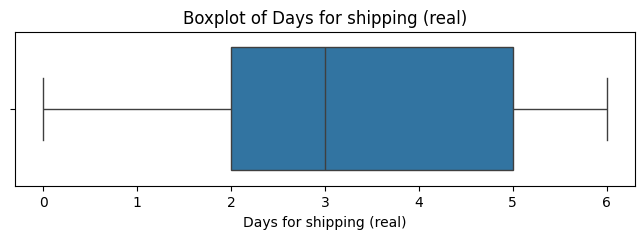

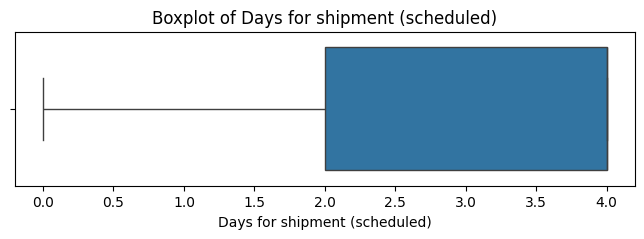

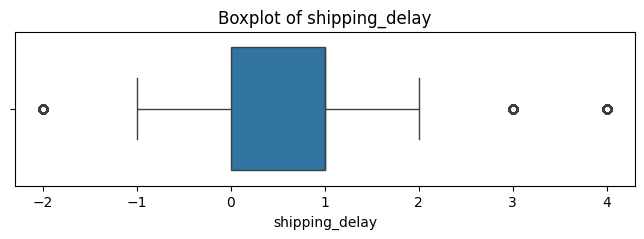

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['Days for shipping (real)', 'Days for shipment (scheduled)', 'shipping_delay']

for col in cols:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [45]:
df[['Days for shipping (real)', 'Days for shipment (scheduled)', 'shipping_delay']].describe()

,Days for shipping (real),Days for shipment (scheduled),shipping_delay
count,180519.000000,180519.000000,180519.000000
mean,3.497654,2.931847,0.565807
std,1.623722,1.374449,1.490966
min,0.000000,0.000000,-2.000000
25%,2.000000,2.000000,0.000000
50%,3.000000,4.000000,1.000000
75%,5.000000,4.000000,1.000000
max,6.000000,4.000000,4.000000


The boxplots and summary statistics show that a few extreme values exist, especially in `shipping_delay`.  
However, these values were retained because they may reflect real operational delays rather than data entry errors.

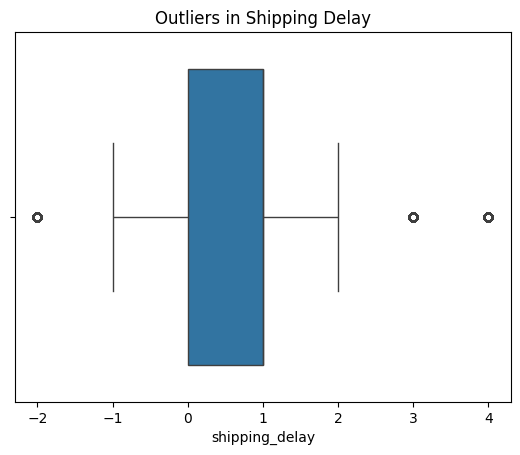

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['shipping_delay'])
plt.title('Outliers in Shipping Delay')
plt.show()

Outliers are observed in shipping_delay.  
These extreme values are kept because they may represent real operational delays.

### Data Cleaning Summary

The following cleaning steps were completed:

- checked missing values
- removed irrelevant columns with excessive missing data
- removed duplicate rows if present
- reviewed data types
- converted date columns into datetime format
- checked consistency of important categorical variables
- reviewed outliers in key delivery-related variables

The cleaned dataset is now ready for feature engineering and analysis.

In [21]:
df['shipping_delay'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']

In [22]:
df['is_late'] = df['shipping_delay'].apply(lambda x: 1 if x > 0 else 0)

## Feature Engineering

We create new variables to analyze shipping delay.

In [23]:
df[['shipping_delay', 'is_late']].head()

,shipping_delay,is_late
0,-1,0
1,1,1
2,0,0
3,-1,0
4,-2,0


In [24]:
df['is_late'].value_counts()

is_late
1    103400
0     77119
Name: count, dtype: int64

## Key Questions and Answers

### 1. What is the late delivery rate?

To understand the overall performance of the logistics system, we calculate the proportion of orders that were delivered late.

Late delivery is defined as:
shipping_delay > 0

In [46]:
late_rate = df['is_late'].mean()
late_rate

np.float64(0.5727928916069777)

 Result:

The late delivery rate is approximately **57.27%**.

 Interpretation:

This means that more than half of the orders are delivered later than scheduled, indicating a significant issue in delivery performance.

 Business Implication:

A high late delivery rate can negatively affect customer satisfaction and operational efficiency.  
This suggests that improving delivery reliability should be a priority for logistics operations.

### 2. What factors are most associated with late deliveries?

We analyze late delivery rates and average shipping delays across key variables:
- Shipping Mode
- Order Region
- Product Category

In [47]:
df.groupby('Shipping Mode')['is_late'].mean().sort_values(ascending=False)

Shipping Mode
First Class       1.000000
Second Class      0.797308
Same Day          0.478279
Standard Class    0.397682
Name: is_late, dtype: float64

 Finding:

Some shipping modes have significantly higher late delivery rates compared to others.

 Interpretation:

This indicates that delivery performance varies depending on the shipping method used.

 Business Implication:

The company should evaluate the performance of different shipping modes and improve or optimize those with higher delay rates.

In [48]:
df.groupby('Order Region')['is_late'].mean().sort_values(ascending=False).head(10)

Order Region
Central Africa     0.607036
Western Europe     0.585156
South Asia         0.585047
South of  USA      0.580964
Southeast Asia     0.579830
East of USA        0.579754
West Asia          0.574971
East Africa        0.574514
Eastern Europe     0.574490
Central America    0.572457
Name: is_late, dtype: float64

 Finding:

Certain regions consistently show higher late delivery rates.

 Interpretation:

This suggests that geographical factors or regional logistics infrastructure may impact delivery efficiency.

 Business Implication:

The company should prioritize operational improvements in high-delay regions.

In [49]:
df.groupby('Category Name')['is_late'].mean().sort_values(ascending=False).head(10)

Category Name
Golf Bags & Carts      0.688525
Lacrosse               0.620991
Cameras                0.619932
Pet Supplies           0.613821
Sporting Goods         0.599440
Basketball             0.597015
Fitness Accessories    0.595469
Crafts                 0.595041
Strength Training      0.594595
Music                  0.594470
Name: is_late, dtype: float64

 Finding:

Some product categories have higher late delivery rates than others.

 Interpretation:

This may be due to differences in product handling, packaging complexity, or warehouse locations.

 Business Implication:

Category-specific shipping strategies may help reduce delays.

### 3. Where is the gap between scheduled and actual shipping time the largest?

We analyze the difference between:
- scheduled shipping days
- actual shipping days

In [50]:
df['shipping_delay'].describe()

count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: shipping_delay, dtype: float64

In [51]:
df.groupby('Shipping Mode')['shipping_delay'].mean().sort_values(ascending=False)

Shipping Mode
Second Class      1.990828
First Class       1.000000
Same Day          0.478279
Standard Class   -0.004093
Name: shipping_delay, dtype: float64

In [52]:
df.groupby('Order Region')['shipping_delay'].mean().sort_values(ascending=False).head(10)

Order Region
Central Asia      0.645570
Central Africa    0.639833
South Asia        0.597465
Western Europe    0.597403
US Center         0.587226
East of USA       0.584816
South of  USA     0.579975
Eastern Europe    0.579847
East Africa       0.570734
West Asia         0.569479
Name: shipping_delay, dtype: float64

 Finding:

The largest delays are observed in certain shipping modes and regions.

 Interpretation:

This indicates that delays are not random but concentrated in specific operational areas.

 Business Implication:

Targeting these high-delay areas can significantly improve overall delivery performance.

### 4. Where should the company focus improvements?

Based on the analysis above, we identify the main areas that require improvement.

In [54]:
# top 5 region delay 
top_regions = df.groupby('Order Region')['shipping_delay'].mean().sort_values(ascending=False).head(5)

# top shipping mode delay 
top_modes = df.groupby('Shipping Mode')['shipping_delay'].mean().sort_values(ascending=False)

top_regions, top_modes

(Order Region
 Central Asia      0.645570
 Central Africa    0.639833
 South Asia        0.597465
 Western Europe    0.597403
 US Center         0.587226
 Name: shipping_delay, dtype: float64,
 Shipping Mode
 Second Class      1.990828
 First Class       1.000000
 Same Day          0.478279
 Standard Class   -0.004093
 Name: shipping_delay, dtype: float64)

 Key Areas for Improvement:

- High-delay shipping modes
- High-delay regions
- High-risk product categories

 Recommendations:

1. Optimize shipping methods with high delay rates  
2. Improve logistics operations in problematic regions  
3. Implement category-specific handling strategies  
4. Monitor and reduce extreme delays  

 Business Value:

By focusing on these areas, the company can significantly improve delivery reliability and customer satisfaction.

## Key Findings and Advanced Analysis
We analyze shipping delays using visualizations.

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

### Late vs On-time Deliveries
This chart shows the number of late and on-time deliveries.

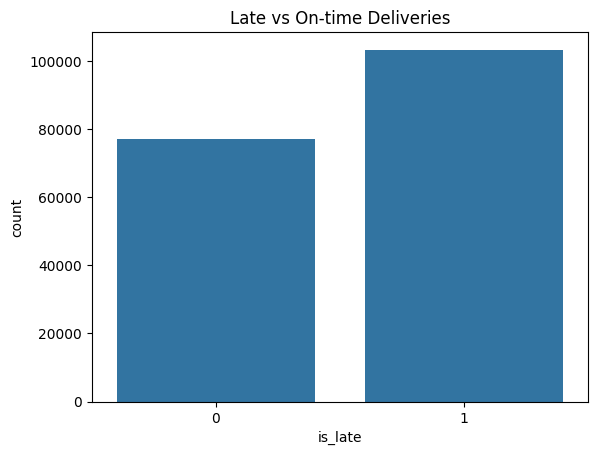

In [26]:
sns.countplot(x='is_late', data=df)
plt.title('Late vs On-time Deliveries')
plt.show()

**Insight:**

The late delivery rate is significantly high (over 57%), indicating systemic inefficiencies in logistics operations rather than isolated issues.
This suggests that delays are not occasional but structural, requiring strategic improvements rather than short-term fixes.

## Distribution of Shipping Delay
This chart shows how shipping delay is distributed across orders.

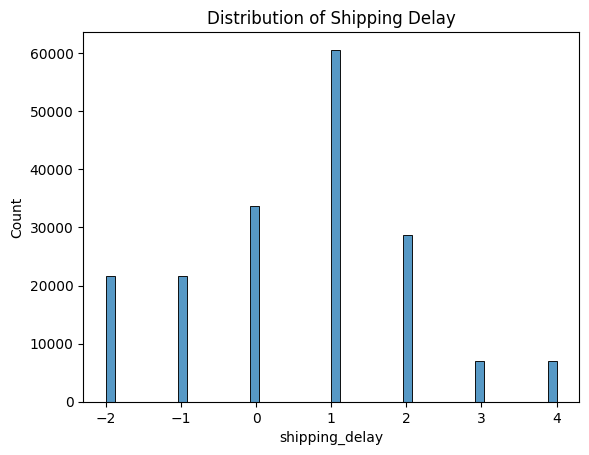

In [27]:
sns.histplot(df['shipping_delay'], bins=50)
plt.title('Distribution of Shipping Delay')
plt.show()

**Insight:**

Most shipping delays are concentrated around small values, but there are also some extreme delays. This suggests that while many orders are only slightly delayed, a smaller number experience serious delay.

## Shipping Mode vs Delay

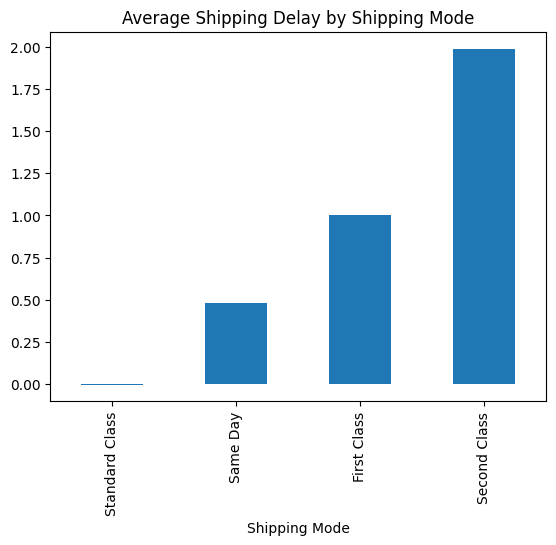

In [31]:
df.groupby('Shipping Mode')['shipping_delay'].mean().sort_values().plot(kind='bar')
plt.title('Average Shipping Delay by Shipping Mode')
plt.show()

**Insight:**  
Some shipping modes have significantly higher average delays, suggesting that delivery method impacts performance.

## Region vs Delay

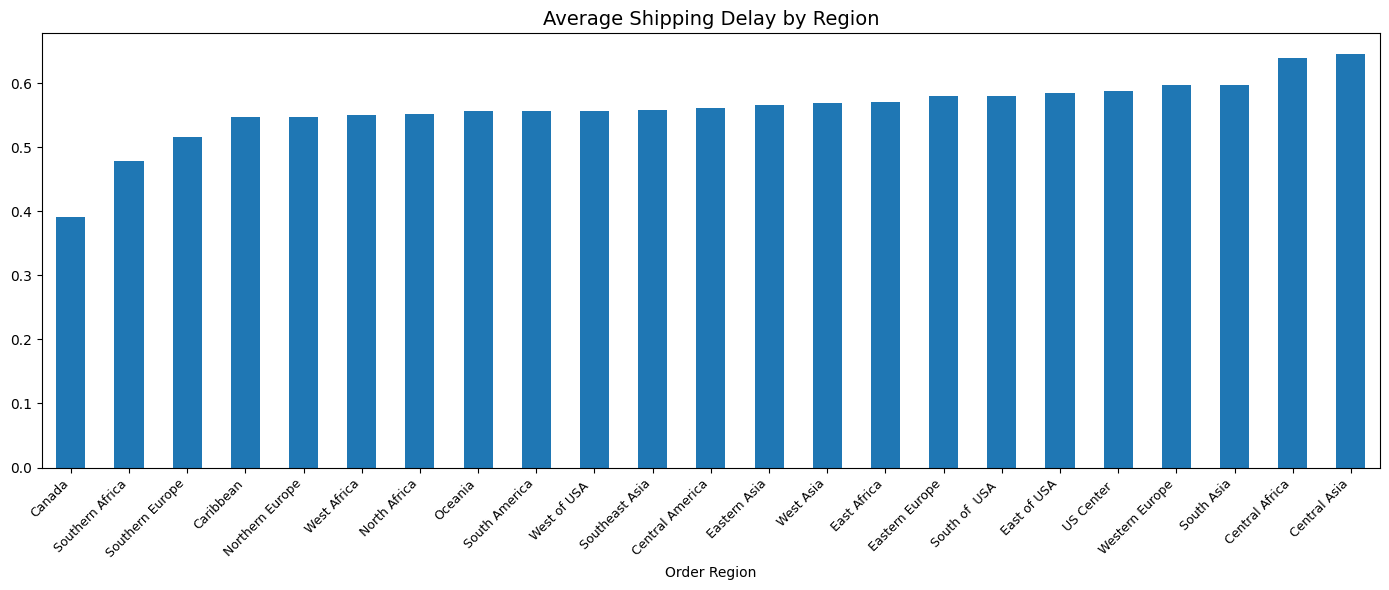

In [65]:
plt.figure(figsize=(14,6))

df.groupby('Order Region')['shipping_delay'].mean().sort_values().plot(kind='bar')

plt.title('Average Shipping Delay by Region', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

**Insight:**  
Certain regions experience higher delays, indicating potential logistical inefficiencies.

### Shipping Mode vs Region

To better understand how shipping performance varies across regions and methods, we analyze the interaction between shipping mode and order region.

In [56]:
pivot_mode_region = df.pivot_table(
    values='shipping_delay',
    index='Order Region',
    columns='Shipping Mode',
    aggfunc='mean'
)

pivot_mode_region

Shipping Mode,First Class,Same Day,Second Class,Standard Class
Order Region,,,,
Canada,1.0,0.333333,2.030120,-0.272569
Caribbean,1.0,0.534368,2.030656,-0.039659
Central Africa,1.0,0.303797,2.127946,0.116883
Central America,1.0,0.486999,1.958219,0.006919
Central Asia,1.0,0.203125,2.213675,0.071197
East Africa,1.0,0.418367,1.922652,0.035971
East of USA,1.0,0.483254,1.972613,0.056174
Eastern Asia,1.0,0.485222,2.115220,-0.020339
Eastern Europe,1.0,0.359551,1.901554,0.035900


In [62]:
pivot_mode_region.idxmax(axis=1).head(10)

Order Region
Canada             Second Class
Caribbean          Second Class
Central Africa     Second Class
Central America    Second Class
Central Asia       Second Class
East Africa        Second Class
East of USA        Second Class
Eastern Asia       Second Class
Eastern Europe     Second Class
North Africa       Second Class
dtype: str

In [63]:
pivot_mode_region.max(axis=1).sort_values(ascending=False).head(10)

Order Region
Central Asia      2.213675
Central Africa    2.127946
Eastern Asia      2.115220
Western Europe    2.056455
South Asia        2.043170
South of  USA     2.038601
Caribbean         2.030656
Canada            2.030120
South America     1.999646
West of USA       1.990196
dtype: float64

**Insight:**

Shipping performance is not uniformly poor across all regions. In many regions, one specific shipping mode is responsible for the highest delay.

This shows that delay problems are not only regional, but also depend on how shipping methods are used within each region.

Instead of applying one general solution, the company should optimize shipping strategies at the region–shipping mode level.

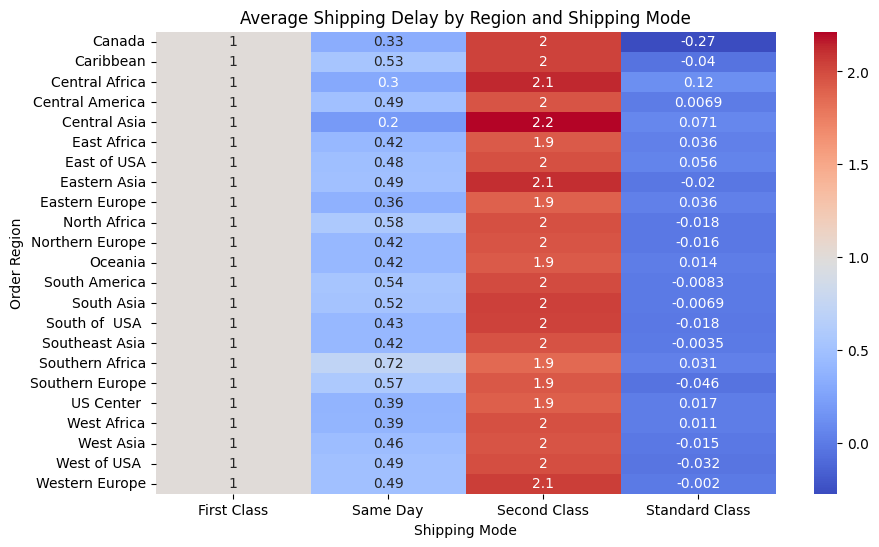

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(pivot_mode_region, annot=True, cmap='coolwarm')
plt.title('Average Shipping Delay by Region and Shipping Mode')
plt.show()

**Finding:**

Shipping Mode and Order Region interact strongly. In many regions, Second Class is the shipping mode with the highest average delay.

**Interpretation:**

This suggests that delivery problems are not only regional, but also depend on how shipping methods are applied within each region.

**Business Implication:**

Instead of using one general logistics strategy, the company should optimize shipping mode selection at the region level, especially for Second Class routes.

### Identifying Top Problem Areas

We identify the regions and shipping modes with the highest average delays to determine where improvements should be prioritized.

In [58]:
top_regions = df.groupby('Order Region')['shipping_delay']\
    .mean().sort_values(ascending=False).head(10)

top_modes = df.groupby('Shipping Mode')['shipping_delay']\
    .mean().sort_values(ascending=False)

top_regions, top_modes

(Order Region
 Central Asia      0.645570
 Central Africa    0.639833
 South Asia        0.597465
 Western Europe    0.597403
 US Center         0.587226
 East of USA       0.584816
 South of  USA     0.579975
 Eastern Europe    0.579847
 East Africa       0.570734
 West Asia         0.569479
 Name: shipping_delay, dtype: float64,
 Shipping Mode
 Second Class      1.990828
 First Class       1.000000
 Same Day          0.478279
 Standard Class   -0.004093
 Name: shipping_delay, dtype: float64)

**Insight:**

Second Class has the highest average shipping delay at about 1.99 days, much higher than Same Day and Standard Class.

Among regions, Central Asia and Central Africa show the highest delays, both above 0.63 days.

This means that the company should focus first on improving Second Class delivery performance and reviewing logistics operations in the highest-delay regions.

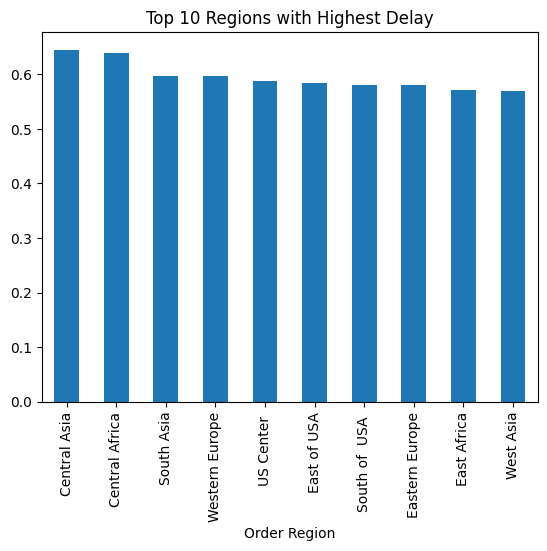

In [59]:
top_regions.plot(kind='bar', title='Top 10 Regions with Highest Delay')
plt.show()

**Finding:**

Central Asia and Central Africa have the highest average shipping delays (above 0.63 days), significantly higher than other regions.

**Interpretation:**

This indicates that these regions are facing consistent logistical inefficiencies, possibly due to longer distances, infrastructure limitations, or inefficient routing.

**Business Implication:**

Improving operations in these regions should be a top priority, as they contribute disproportionately to overall delays.

### Distribution of Shipping Delay

We examine how shipping delays are distributed to understand how frequently extreme delays occur.

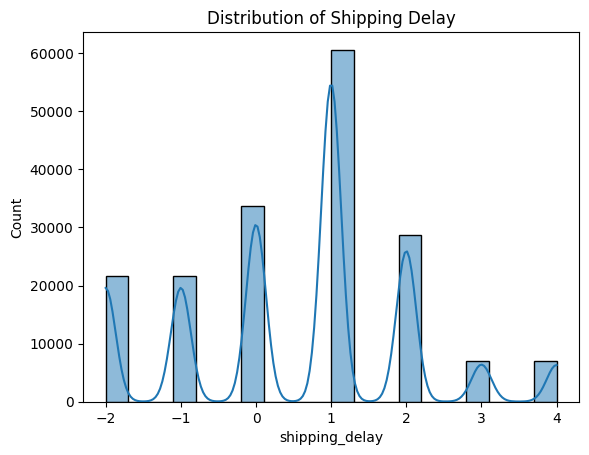

In [60]:
sns.histplot(df['shipping_delay'], bins=20, kde=True)
plt.title('Distribution of Shipping Delay')
plt.show()

**Finding:**

Most shipping delays are concentrated around small positive values, but some extreme delays are also observed.

**Interpretation:**

This suggests that while minor delays are common, severe delays occur less frequently but may have a strong impact on customer satisfaction.

**Business Implication:**

Reducing frequent small delays and preventing extreme delays should both be considered in logistics optimization strategies.

In [61]:
df.groupby(['Category Name', 'Shipping Mode'])['is_late'].mean().unstack()

Shipping Mode,First Class,Same Day,Second Class,Standard Class
Category Name,,,,
Accessories,1.0,0.488636,0.808333,0.411708
As Seen on TV!,1.0,0.333333,0.928571,0.390244
Baby,1.0,0.555556,0.758621,0.358974
Baseball & Softball,1.0,0.533333,0.804511,0.354396
Basketball,1.0,NaN,1.000000,0.341463
Books,1.0,0.750000,0.750000,0.405738
Boxing & MMA,1.0,0.551724,0.789474,0.400862
CDs,1.0,0.444444,0.727273,0.400000
Cameras,1.0,0.363636,0.817391,0.372937


## Final Insights

The analysis consistently shows that shipping delays are concentrated in specific operational areas rather than being evenly spread across all orders.

This means that logistics companies can improve delivery performance more effectively by focusing on the most problematic shipping modes, regions, and route combinations.

## Conclusion

This project analyzed shipping delays in logistics operations using the DataCo supply chain dataset.

The analysis shows that late delivery is a significant issue, with more than half of orders being delivered later than scheduled. Shipping delays are not evenly distributed across the dataset. Instead, they are concentrated in specific shipping modes, regions, and product categories.

Among the main findings:
- the late delivery rate is high at approximately 57.27%
- some regions, such as Central Asia and Central Africa, show the highest average shipping delays
- Second Class has the highest average shipping delay among shipping modes
- delay patterns vary across region–shipping mode combinations, showing that performance problems are not uniform

Overall, the findings suggest that logistics inefficiencies are systematic rather than random. Therefore, companies should focus on region-specific and shipping-mode-specific improvements to reduce delays and improve delivery reliability.

## Limitations

This project has several limitations.

First, the dataset does not provide enough contextual operational details to fully explain why delays happen in specific regions or shipping modes.

Second, the analysis is based on historical data from a public dataset, so the findings may not fully represent current logistics conditions.

Third, this project focuses mainly on descriptive and comparative analysis, rather than predictive modeling or causal testing.

Therefore, the results should be interpreted as data-driven insights rather than definitive causal conclusions.

## Future Work

This analysis can be extended in several ways.

Future work could include:
- building a predictive model to estimate late delivery risk
- testing whether shipping mode and region have statistically significant effects on delays
- analyzing category-level and region-level interactions in more detail
- incorporating additional operational variables, such as warehouse performance or route characteristics

These extensions could help transform descriptive insights into stronger decision-support tools for logistics management.